# Notebook 2 — Classification Modelling & Hyperparameter Tuning

This notebook builds, evaluates, and tunes classification models to predict **loan approval status** (0 = Approved, 1 = Rejected).  
We train Logistic Regression, K-Nearest Neighbours, and Gaussian Naive Bayes, compare their performance using **recall** as the primary metric (to maximise detection of rejected loans), and apply hyperparameter tuning via GridSearchCV.

---
## Part A — Load Data from Preprocessing Notebook

We run Notebook 1 (`loan_data_preprocessing.ipynb`) to load and preprocess the data.  
A safety check ensures the required variables (`X_classification_scaled`, `y_classification`) are available before proceeding.

### Step 1 — Run Preprocessing Notebook

We use the `%run` magic command to execute the preprocessing notebook and import all its variables into this notebook's namespace.

=== First 5 Rows of the Dataset ===
=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  str    
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  str    
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  str    
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7)

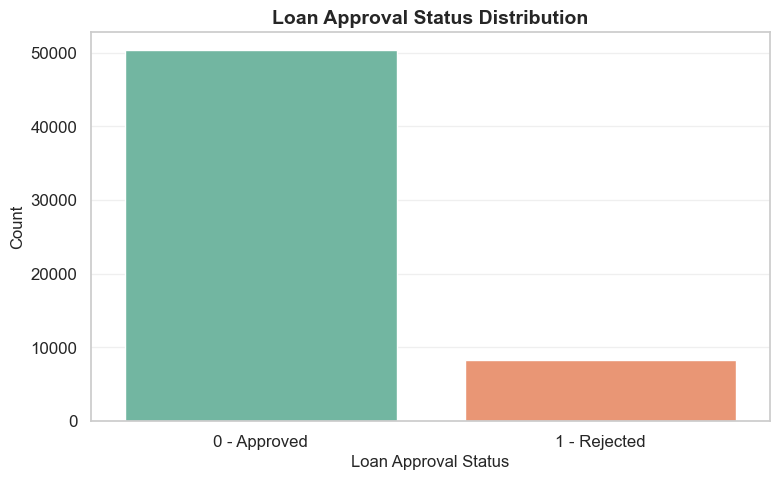

Total Applications: 58645
Approved: 50295 (85.76%)
Rejected: 8350 (14.24%)
=== Regression Dataset Created (Approved Loans Only) ===
X_regression shape: (50295, 10)
y_regression shape: (50295,)

=== Regression Target Statistics ===
count    5.029500e+04
mean     8.133543e+04
std      5.919723e+04
min     -2.426900e+06
25%      4.909150e+04
50%      6.942700e+04
75%      9.898900e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64
=== Feature Scaling Complete ===
X_classification_scaled shape: (58645, 11)
X_classification_scaled type:  <class 'pandas.DataFrame'>

X_regression_scaled shape:    (50295, 10)
X_regression_scaled type:     <class 'pandas.DataFrame'>
=== Final Variable Types ===
X_classification_scaled: <class 'pandas.DataFrame'>
y_classification dtype:  int64
X_regression_scaled:     <class 'pandas.DataFrame'>
y_regression dtype:      int64

PREPROCESSING COMPLETE - FINAL SUMMARY

=== Classification Dataset ===
X_classification shape:        (58645, 11)
X_classifi

In [1]:
# Run the preprocessing notebook to load all prepared variables
%run loan_data_preprocessing.ipynb

### Step 2 — Safety Check and Variable Assignment

We verify that the required variables exist, then assign them to shorter names (`X`, `y`) for convenience throughout the notebook.

In [2]:
# Safety check: ensure X_classification_scaled exists from Notebook 1
if 'X_classification_scaled' not in dir():
    raise RuntimeError('X_classification_scaled not found. Please run Notebook 1 first.')

# Safety check: ensure y_classification exists from Notebook 1
if 'y_classification' not in dir():
    raise RuntimeError('y_classification not found. Please run Notebook 1 first.')

# Assign the scaled features to X for convenience
X = X_classification_scaled

# Assign the target variable to y for convenience
y = y_classification

# Print a header for the data summary
print('=== Data Loaded Successfully ===')

# Print the shape of the feature matrix
print(f'X shape: {X.shape}')

# Print the shape of the target vector
print(f'y shape: {y.shape}')

# Print the feature names
print(f'\n=== Feature Names ===')
print(list(X.columns))

=== Data Loaded Successfully ===
X shape: (58645, 11)
y shape: (58645,)

=== Feature Names ===
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed_loan']


---
## Part B — Train-Test Split

We split the data into training (80%) and testing (20%) sets using stratified sampling to preserve the class distribution in both sets.  
A fixed `random_state=42` ensures reproducibility.

### Steps 4 & 5 — Split and Verify Class Distribution

We use `train_test_split` with stratification and print the shapes and class distributions of both sets.

In [3]:
# Import the train_test_split function
from sklearn.model_selection import train_test_split

# Split the data: 80% training, 20% testing, stratified by target
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print a header for the split summary
print('=== Train-Test Split Complete ===')

# Print the shape of the training features
print(f'X_train shape: {X_train.shape}')

# Print the shape of the testing features
print(f'X_test shape:  {X_test.shape}')

# Print the shape of the training target
print(f'y_train shape: {y_train.shape}')

# Print the shape of the testing target
print(f'y_test shape:  {y_test.shape}')

# Print a header for the class distribution
print('\n=== Class Distribution (Training Set) ===')

# Display the value counts for the training target
print(y_train.value_counts().sort_index())

# Print a header for the test class distribution
print('\n=== Class Distribution (Test Set) ===')

# Display the value counts for the testing target
print(y_test.value_counts().sort_index())

=== Train-Test Split Complete ===
X_train shape: (46916, 11)
X_test shape:  (11729, 11)
y_train shape: (46916,)
y_test shape:  (11729,)

=== Class Distribution (Training Set) ===
loan_approval_status
0    40236
1     6680
Name: count, dtype: int64

=== Class Distribution (Test Set) ===
loan_approval_status
0    10059
1     1670
Name: count, dtype: int64


---
## Part C — Build Classification Models

We create three classification models:  
1. **Logistic Regression** — a linear model suitable for binary classification  
2. **K-Nearest Neighbours (KNN)** — an instance-based learner using distance metrics  
3. **Gaussian Naive Bayes** — a probabilistic classifier assuming feature independence  

All models are stored in a dictionary for easy iteration during training and evaluation.

### Steps 6 & 7 — Create and Store Models

We instantiate each model and place them into a dictionary keyed by model name.

In [4]:
# Import Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

# Import K-Nearest Neighbours classifier
from sklearn.neighbors import KNeighborsClassifier

# Import Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

# Create a dictionary to store all models for easy iteration
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

# Print confirmation of models created
print('=== Models Created ===')

# Loop through and print each model name
for name in models:
    print(f'  • {name}')

=== Models Created ===
  • Logistic Regression
  • KNN
  • Naive Bayes


---
## Part D — Train & Evaluate All Models

We loop through each model, train it on the training set, generate predictions, and compute key classification metrics.  

**Recall (Reject class)** is our priority metric because failing to identify a rejected loan application is more costly than a false alarm. We use `pos_label=1` to compute recall for the rejection class.

### Steps 8–11 — Training Loop with Full Evaluation

For each model we:  
- Train on the training data  
- Predict class labels and probability scores  
- Compute accuracy, recall, precision, F1-score, and AUC-ROC  
- Display the confusion matrix and classification report  
- Store all results in a dictionary for later comparison

In [5]:
# Import required evaluation metrics
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Create a dictionary to store evaluation results for all models
results = {}

# Loop through each model in the dictionary
for name, model in models.items():

    # Print a header for this model's evaluation
    print('\n' + '=' * 60)
    print(f'MODEL: {name}')
    print('=' * 60)

    # Train the model on the training data
    model.fit(X_train, y_train)

    # Generate predicted class labels on the test set
    y_pred = model.predict(X_test)

    # Generate predicted probability scores for the positive class
    y_score = model.predict_proba(X_test)[:, 1]

    # Compute accuracy
    acc = accuracy_score(y_test, y_pred)

    # Compute recall for the reject class (pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)

    # Compute precision for the reject class (pos_label=1, zero_division=0)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)

    # Compute F1-score for the reject class
    f1 = f1_score(y_test, y_pred, pos_label=1)

    # Compute the AUC-ROC score using probability scores
    auc = roc_auc_score(y_test, y_score)

    # Print the confusion matrix
    print('\n--- Confusion Matrix ---')
    print(confusion_matrix(y_test, y_pred))

    # Print the full classification report
    print('\n--- Classification Report ---')
    print(classification_report(y_test, y_pred, zero_division=0))

    # Print the metric summary
    print('--- Metric Summary ---')
    print(f'  Accuracy:              {acc:.4f}')
    print(f'  Recall (Reject class): {rec:.4f}')
    print(f'  Precision:             {prec:.4f}')
    print(f'  F1-Score:              {f1:.4f}')
    print(f'  AUC-ROC:               {auc:.4f}')

    # Store all metrics in the results dictionary
    results[name] = {
        'model': model,
        'accuracy': acc,
        'recall': rec,
        'precision': prec,
        'f1': f1,
        'auc': auc,
        'y_pred': y_pred,
        'y_score': y_score
    }

# Print confirmation that all models have been evaluated
print('\n' + '=' * 60)
print('All models trained and evaluated successfully.')
print('=' * 60)


MODEL: Logistic Regression

--- Confusion Matrix ---
[[10024    35]
 [    2  1668]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10059
           1       0.98      1.00      0.99      1670

    accuracy                           1.00     11729
   macro avg       0.99      1.00      0.99     11729
weighted avg       1.00      1.00      1.00     11729

--- Metric Summary ---
  Accuracy:              0.9968
  Recall (Reject class): 0.9988
  Precision:             0.9794
  F1-Score:              0.9890
  AUC-ROC:               0.9999

MODEL: KNN

--- Confusion Matrix ---
[[9991   68]
 [ 184 1486]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     10059
           1       0.96      0.89      0.92      1670

    accuracy                           0.98     11729
   macro avg       0.97      0.94      0.95     11729
weight

---
## Part E — ROC Curve Comparison

We plot the Receiver Operating Characteristic (ROC) curve for all three models on the same graph.  
The ROC curve shows the trade-off between True Positive Rate (sensitivity) and False Positive Rate. A higher AUC indicates better model discrimination.

### Step 12 — Plot ROC Curves for All Models

Each model's ROC curve is drawn with its AUC score displayed in the legend.

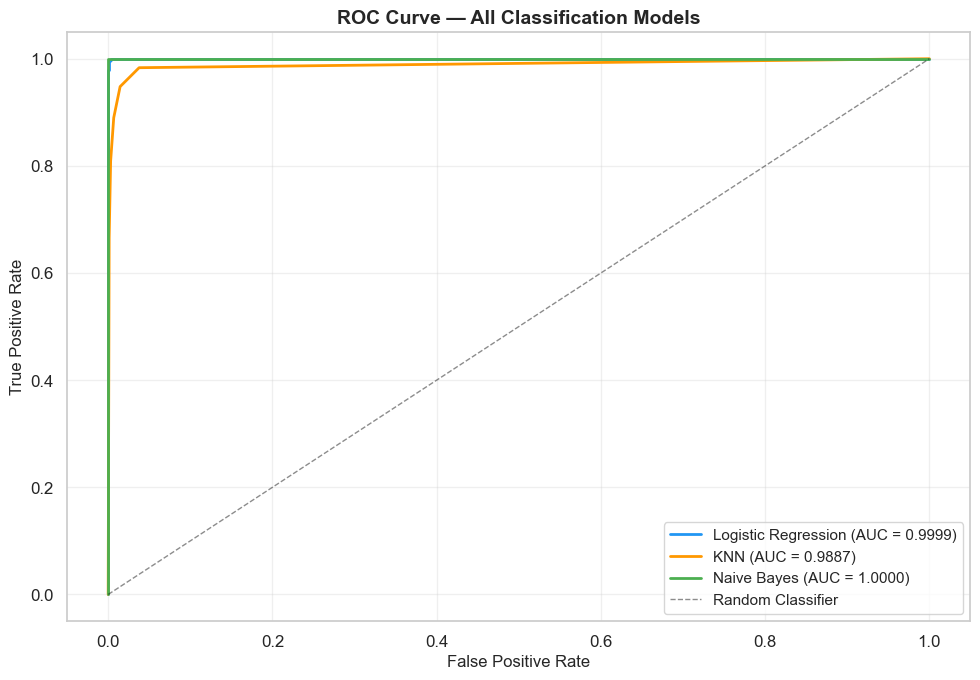

In [6]:
# Import the ROC curve function
from sklearn.metrics import roc_curve

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a new figure with specified dimensions
plt.figure(figsize=(10, 7))

# Define colours for each model's ROC curve
colors = ['#2196F3', '#FF9800', '#4CAF50']

# Loop through each model to plot its ROC curve
for idx, (name, res) in enumerate(results.items()):

    # Compute FPR, TPR, and thresholds for this model
    fpr, tpr, _ = roc_curve(y_test, res['y_score'])

    # Plot the ROC curve with AUC in the label
    plt.plot(fpr, tpr, color=colors[idx], linewidth=2,
             label=f"{name} (AUC = {res['auc']:.4f})")

# Plot the diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

# Set the plot title
plt.title('ROC Curve — All Classification Models', fontsize=14, fontweight='bold')

# Set the x-axis label
plt.xlabel('False Positive Rate', fontsize=12)

# Set the y-axis label
plt.ylabel('True Positive Rate', fontsize=12)

# Add the legend to the lower-right corner
plt.legend(loc='lower right', fontsize=11)

# Add gridlines for readability
plt.grid(alpha=0.3)

# Adjust layout to prevent label clipping
plt.tight_layout()

# Display the plot
plt.show()

---
## Part F — Model Comparison Table

We compile all metrics into a single pandas DataFrame for a clear side-by-side comparison of all models.

### Steps 13 & 14 — Create and Print Comparison Table

The table includes Accuracy, Recall (Reject class), Precision, F1-Score, and AUC-ROC for each model.

In [7]:
# Import pandas for table creation
import pandas as pd

# Build a list of dictionaries, one per model, for the comparison table
comparison_data = []

# Loop through each model's results to extract metrics
for name, res in results.items():

    # Append a dictionary of metrics for this model
    comparison_data.append({
        'Model': name,
        'Accuracy': round(res['accuracy'], 4),
        'Recall (Reject)': round(res['recall'], 4),
        'Precision': round(res['precision'], 4),
        'F1-Score': round(res['f1'], 4),
        'AUC-ROC': round(res['auc'], 4)
    })

# Create a DataFrame from the comparison data
comparison_df = pd.DataFrame(comparison_data)

# Set the Model column as the index for cleaner display
comparison_df = comparison_df.set_index('Model')

# Print a header for the comparison table
print('=== Model Comparison Table ===')

# Display the comparison DataFrame
print(comparison_df.to_string())

=== Model Comparison Table ===
                     Accuracy  Recall (Reject)  Precision  F1-Score  AUC-ROC
Model                                                                       
Logistic Regression    0.9968           0.9988     0.9794    0.9890   0.9999
KNN                    0.9785           0.8898     0.9562    0.9218   0.9887
Naive Bayes            0.9997           0.9976     1.0000    0.9988   1.0000


---
## Part G — Best Model Selection

We select the best model based on **Recall (Reject class)**.  

**Why Recall?** In loan approval, failing to detect a risky application that should be rejected (a False Negative) is more dangerous than incorrectly flagging a good application. High recall ensures we catch as many rejected-class cases as possible.

### Steps 15 & 16 — Select and Print the Best Model

We use the recall metric to identify the top-performing model and print all of its metrics.

In [8]:
# Select the model name with the highest recall score
best_model_name = max(results, key=lambda x: results[x]['recall'])

# Retrieve the results dictionary for the best model
best_model_metrics = results[best_model_name]

# Print a header for the best model selection
print('=' * 60)
print('BEST MODEL SELECTION (Based on Recall)')
print('=' * 60)

# Print an explanation of why recall is the priority
print('\nPriority: Recall (Reject class) — detecting rejected loans')
print('Rationale: Missing a risky loan (False Negative) is costlier')
print('           than flagging a safe loan (False Positive).')

# Print the selected best model name
print(f'\n>>> Best Model: {best_model_name} <<<')

# Print all metrics for the best model
print(f'\n  Accuracy:              {best_model_metrics["accuracy"]:.4f}')
print(f'  Recall (Reject class): {best_model_metrics["recall"]:.4f}')
print(f'  Precision:             {best_model_metrics["precision"]:.4f}')
print(f'  F1-Score:              {best_model_metrics["f1"]:.4f}')
print(f'  AUC-ROC:               {best_model_metrics["auc"]:.4f}')

# Print the closing separator
print('=' * 60)

BEST MODEL SELECTION (Based on Recall)

Priority: Recall (Reject class) — detecting rejected loans
Rationale: Missing a risky loan (False Negative) is costlier
           than flagging a safe loan (False Positive).

>>> Best Model: Logistic Regression <<<

  Accuracy:              0.9968
  Recall (Reject class): 0.9988
  Precision:             0.9794
  F1-Score:              0.9890
  AUC-ROC:               0.9999


---
## Part H — Hyperparameter Tuning (GridSearchCV)

We use **GridSearchCV** with 5-fold cross-validation to find the optimal hyperparameters for the best model.  
The scoring metric is set to **recall** to stay consistent with our model selection criterion.

### Steps 17 & 18 — Define Parameter Grids

We define parameter grids for all three models and select the correct grid based on the best model identified above.

In [9]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Import numpy for generating parameter ranges
import numpy as np

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Define the parameter grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21]
}

# Define the parameter grid for Naive Bayes
param_grid_nb = {
    'var_smoothing': np.logspace(-12, -6, 7)
}

# Create a mapping of model names to their parameter grids
param_grids = {
    'Logistic Regression': param_grid_lr,
    'KNN': param_grid_knn,
    'Naive Bayes': param_grid_nb
}

# Select the parameter grid that corresponds to the best model
selected_param_grid = param_grids[best_model_name]

# Print the selected model and its parameter grid
print(f'=== Hyperparameter Grid for: {best_model_name} ===')
print(selected_param_grid)

=== Hyperparameter Grid for: Logistic Regression ===
{'C': [0.001, 0.01, 0.1, 1, 10, 100]}


### Steps 19, 20 & 21 — Run GridSearchCV

We run the grid search with `scoring='recall'`, `cv=5`, and `n_jobs=-1` (parallel processing). After fitting, we print the best parameters and the best cross-validation recall score.

In [10]:
# Get a fresh instance of the best model for tuning
base_model = models[best_model_name]

# Create the GridSearchCV object with recall scoring and 5-fold CV
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=selected_param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=0
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Print a header for the grid search results
print('=== GridSearchCV Results ===')

# Print the best hyperparameters found
print(f'Best Parameters: {grid_search.best_params_}')

# Print the best cross-validation recall score
print(f'Best CV Recall Score: {grid_search.best_score_:.4f}')

=== GridSearchCV Results ===
Best Parameters: {'C': 0.1}
Best CV Recall Score: 0.9993


---
## Part I — Tuned Model Evaluation

We evaluate the tuned model (the best estimator from GridSearchCV) on the held-out test set using the same metrics as before.

### Steps 22–25 — Predict and Compute Tuned Metrics

We use `grid_search.best_estimator_` to generate predictions and compute all classification metrics.

In [11]:
# Retrieve the best estimator from the grid search
tuned_model = grid_search.best_estimator_

# Generate predicted class labels on the test set
y_pred_tuned = tuned_model.predict(X_test)

# Generate predicted probability scores for the positive class
y_score_tuned = tuned_model.predict_proba(X_test)[:, 1]

# Compute accuracy for the tuned model
acc_tuned = accuracy_score(y_test, y_pred_tuned)

# Compute recall for the reject class (pos_label=1)
rec_tuned = recall_score(y_test, y_pred_tuned, pos_label=1)

# Compute precision for the reject class (pos_label=1, zero_division=0)
prec_tuned = precision_score(y_test, y_pred_tuned, pos_label=1, zero_division=0)

# Compute F1-score for the reject class
f1_tuned = f1_score(y_test, y_pred_tuned, pos_label=1)

# Compute AUC-ROC using probability scores
auc_tuned = roc_auc_score(y_test, y_score_tuned)

# Print the tuned model evaluation header
print('=' * 60)
print(f'TUNED MODEL EVALUATION: {best_model_name}')
print('=' * 60)

# Print the confusion matrix
print('\n--- Confusion Matrix ---')
print(confusion_matrix(y_test, y_pred_tuned))

# Print the full classification report
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred_tuned, zero_division=0))

# Print the metric summary
print('--- Metric Summary ---')
print(f'  Accuracy:              {acc_tuned:.4f}')
print(f'  Recall (Reject class): {rec_tuned:.4f}')
print(f'  Precision:             {prec_tuned:.4f}')
print(f'  F1-Score:              {f1_tuned:.4f}')
print(f'  AUC-ROC:               {auc_tuned:.4f}')
print('=' * 60)

TUNED MODEL EVALUATION: Logistic Regression

--- Confusion Matrix ---
[[10011    48]
 [    4  1666]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10059
           1       0.97      1.00      0.98      1670

    accuracy                           1.00     11729
   macro avg       0.99      1.00      0.99     11729
weighted avg       1.00      1.00      1.00     11729

--- Metric Summary ---
  Accuracy:              0.9956
  Recall (Reject class): 0.9976
  Precision:             0.9720
  F1-Score:              0.9846
  AUC-ROC:               0.9998


---
## Part J — Before vs After Tuning Comparison

We compare the model's performance before and after hyperparameter tuning to quantify the improvement achieved through GridSearchCV.

### Steps 26 & 27 — Confusion Matrices and Metric Comparison

We display both confusion matrices side by side and create a comparison table highlighting changes in recall.

In [12]:
# Print the comparison header
print('=' * 60)
print(f'BEFORE vs AFTER TUNING: {best_model_name}')
print('=' * 60)

# Print the confusion matrix BEFORE tuning
print('\n--- Confusion Matrix (BEFORE Tuning) ---')
print(confusion_matrix(y_test, best_model_metrics['y_pred']))

# Print the confusion matrix AFTER tuning
print('\n--- Confusion Matrix (AFTER Tuning) ---')
print(confusion_matrix(y_test, y_pred_tuned))

# Build the before-after comparison data
before_after_data = {
    'Metric': ['Accuracy', 'Recall (Reject)', 'Precision', 'F1-Score', 'AUC-ROC'],
    'Before Tuning': [
        round(best_model_metrics['accuracy'], 4),
        round(best_model_metrics['recall'], 4),
        round(best_model_metrics['precision'], 4),
        round(best_model_metrics['f1'], 4),
        round(best_model_metrics['auc'], 4)
    ],
    'After Tuning': [
        round(acc_tuned, 4),
        round(rec_tuned, 4),
        round(prec_tuned, 4),
        round(f1_tuned, 4),
        round(auc_tuned, 4)
    ]
}

# Create a DataFrame for the comparison
before_after_df = pd.DataFrame(before_after_data)

# Calculate the change for each metric
before_after_df['Change'] = before_after_df['After Tuning'] - before_after_df['Before Tuning']

# Round the change column to 4 decimal places
before_after_df['Change'] = before_after_df['Change'].round(4)

# Set Metric as the index for cleaner display
before_after_df = before_after_df.set_index('Metric')

# Print the comparison table header
print('\n--- Performance Comparison ---')

# Display the full comparison table
print(before_after_df.to_string())

# Calculate the recall change for highlighting
recall_change = rec_tuned - best_model_metrics['recall']

# Print the recall improvement highlight
print(f'\n>>> Recall Change: {recall_change:+.4f} <<<')

# Print interpretation of the recall change
if recall_change > 0:
    print(f'    Recall IMPROVED by {recall_change:.4f} after tuning.')
elif recall_change < 0:
    print(f'    Recall DECREASED by {abs(recall_change):.4f} after tuning.')
else:
    print('    Recall remained UNCHANGED after tuning.')

# Print the closing separator
print('=' * 60)

BEFORE vs AFTER TUNING: Logistic Regression

--- Confusion Matrix (BEFORE Tuning) ---
[[10024    35]
 [    2  1668]]

--- Confusion Matrix (AFTER Tuning) ---
[[10011    48]
 [    4  1666]]

--- Performance Comparison ---
                 Before Tuning  After Tuning  Change
Metric                                              
Accuracy                0.9968        0.9956 -0.0012
Recall (Reject)         0.9988        0.9976 -0.0012
Precision               0.9794        0.9720 -0.0074
F1-Score                0.9890        0.9846 -0.0044
AUC-ROC                 0.9999        0.9998 -0.0001

>>> Recall Change: -0.0012 <<<
    Recall DECREASED by 0.0012 after tuning.


---
## Part K — Final ROC Curve (Tuned Model)

We plot the ROC curve for the tuned model to visualise its classification performance after hyperparameter optimisation.

### Step 28 — Plot ROC Curve for Tuned Model

The final ROC curve shows the tuned model's ability to discriminate between approved and rejected loans.

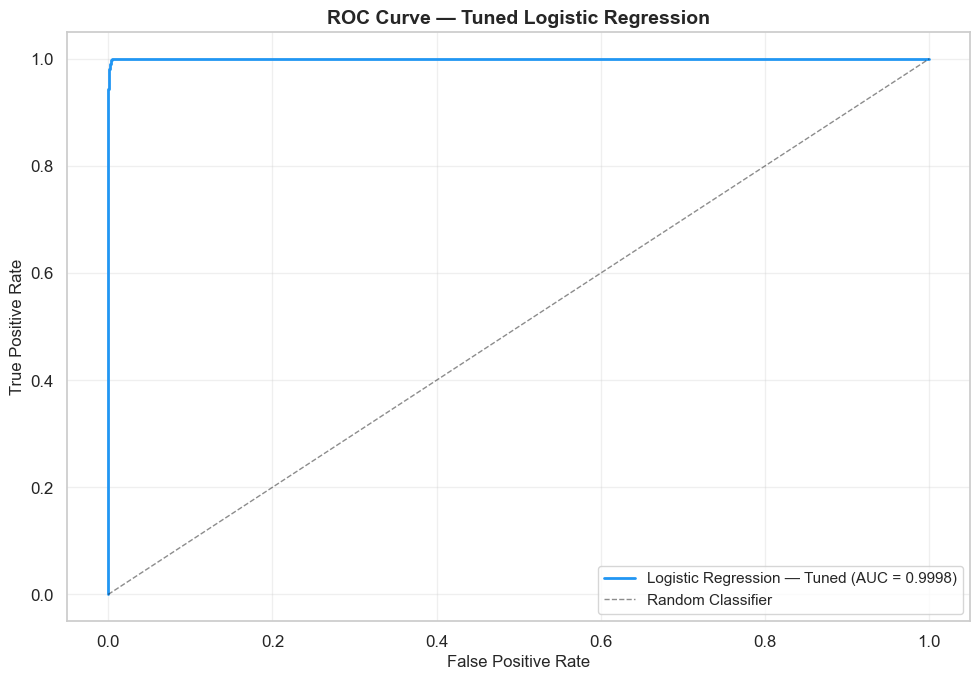

In [13]:
# Compute FPR and TPR for the tuned model
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_score_tuned)

# Create a new figure with specified dimensions
plt.figure(figsize=(10, 7))

# Plot the ROC curve for the tuned model
plt.plot(fpr_tuned, tpr_tuned, color='#2196F3', linewidth=2,
         label=f'{best_model_name} — Tuned (AUC = {auc_tuned:.4f})')

# Plot the diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

# Set the plot title
plt.title(f'ROC Curve — Tuned {best_model_name}', fontsize=14, fontweight='bold')

# Set the x-axis label
plt.xlabel('False Positive Rate', fontsize=12)

# Set the y-axis label
plt.ylabel('True Positive Rate', fontsize=12)

# Add the legend
plt.legend(loc='lower right', fontsize=11)

# Add gridlines for readability
plt.grid(alpha=0.3)

# Adjust layout to prevent label clipping
plt.tight_layout()

# Display the plot
plt.show()

---
## Part L — Final Summary

This section provides a complete summary of the classification modelling process, including dataset information, all model performances, the best model selection, and the final tuned results.

### Step 29 — Complete Summary

We print all key information in a single consolidated output for coursework reference.

In [14]:
# Print the opening banner
print('\n' + '=' * 60)
print('NOTEBOOK 2 — FINAL SUMMARY')
print('=' * 60)

# Print the dataset information header
print('\n=== Dataset Information ===')

# Print the total dataset shape
print(f'Total samples:   {X.shape[0]}')

# Print the number of features
print(f'Total features:  {X.shape[1]}')

# Print the training set size
print(f'Training set:    {X_train.shape[0]}')

# Print the test set size
print(f'Test set:        {X_test.shape[0]}')

# Print the model performance header
print('\n=== All Models — Recall (Reject Class) ===')

# Loop through each model and print its recall score
for name, res in results.items():
    print(f'  {name:25s} Recall = {res["recall"]:.4f}')

# Print the best model header
print(f'\n=== Best Model: {best_model_name} ===')

# Print the best hyperparameters
print(f'Best Parameters: {grid_search.best_params_}')

# Print the tuned performance header
print('\n=== Tuned Model Performance ===')

# Print tuned accuracy
print(f'  Accuracy:              {acc_tuned:.4f}')

# Print tuned recall
print(f'  Recall (Reject class): {rec_tuned:.4f}')

# Print tuned precision
print(f'  Precision:             {prec_tuned:.4f}')

# Print tuned F1-score
print(f'  F1-Score:              {f1_tuned:.4f}')

# Print tuned AUC-ROC
print(f'  AUC-ROC:               {auc_tuned:.4f}')

# Print the closing confirmation
print('\n✓ Classification modelling and tuning complete.')
print('✓ Ready for Notebook 3 (Ensemble & Regression).')
print('=' * 60)


NOTEBOOK 2 — FINAL SUMMARY

=== Dataset Information ===
Total samples:   58645
Total features:  11
Training set:    46916
Test set:        11729

=== All Models — Recall (Reject Class) ===
  Logistic Regression       Recall = 0.9988
  KNN                       Recall = 0.8898
  Naive Bayes               Recall = 0.9976

=== Best Model: Logistic Regression ===
Best Parameters: {'C': 0.1}

=== Tuned Model Performance ===
  Accuracy:              0.9956
  Recall (Reject class): 0.9976
  Precision:             0.9720
  F1-Score:              0.9846
  AUC-ROC:               0.9998

✓ Classification modelling and tuning complete.
✓ Ready for Notebook 3 (Ensemble & Regression).
